# Q2b: Causal Indicators of Participant Progression & Risk

**Goal:** Identify statistically significant predictors of progression and regression
across three outcome targets, using features from four resident-linked tables:
health, process recordings, home visitations, and education records.

**Three target models:**

| # | Target | Type | Level |
|---|--------|------|-------|
| 1 | `risk_delta` (initial − current risk) | Ordinal 0–3 | Resident (n=60) |
| 2 | `pct_progress_noted` (social-worker flag) | Proportion 0–1 | Resident-month panel (n≈534) |
| 3 | `general_health_score` | Continuous 1–5 | Resident-month panel (n≈534) |

**Methods:** OLS and ordinal logistic with clustered standard errors,
fixed-effects panel estimator, full diagnostics (VIF, Breusch–Pagan, normality).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
CLEAN = "cleaned"

## 1. Data Loading & Table Linkage

All four source tables join to **residents** on `resident_id`.
The `resident_timeline.csv` pre-aggregates them into a single resident-month panel.

```
residents (n=60)
  ├──► health_wellbeing_records   ──► general_health_score, nutrition, sleep, energy, bmi
  ├──► education_records          ──► attendance_rate, progress_percent
  ├──► process_recordings         ──► session_count, pct_progress_noted, pct_concerns, emotional_improvement
  └──► home_visitations           ──► visit_count, avg_cooperation, pct_safety_concerns, pct_favorable
                 │
                 ▼
       resident_timeline.csv  (534 rows × 67 cols)
       one row per resident per month
```

In [2]:
tl = pd.read_csv(f"{CLEAN}/resident_timeline.csv", parse_dates=["record_date"])
residents = pd.read_csv(f"{CLEAN}/residents.csv")

bool_cols = [c for c in tl.columns if tl[c].dtype == object and
             set(tl[c].dropna().unique()).issubset({"True","False","true","false",True,False})]
for c in bool_cols:
    tl[c] = tl[c].astype(str).str.lower().map({"true": 1, "false": 0})

tl["case_category_enc"] = LabelEncoder().fit_transform(tl["case_category"].astype(str))

print(f"Panel: {tl.shape[0]} rows × {tl.shape[1]} cols")
print(f"Unique residents: {tl['resident_id'].nunique()}")
print(f"Date range: {tl['record_date'].min().date()} to {tl['record_date'].max().date()}")
print(f"\nTarget distributions:")
print(tl[["risk_delta","pct_progress_noted","general_health_score"]].describe().round(3))

Panel: 534 rows × 68 cols
Unique residents: 60
Date range: 2023-01-01 to 2026-02-01

Target distributions:
       risk_delta  pct_progress_noted  general_health_score
count     534.000             462.000               534.000
mean        0.654               0.943                 3.195
std         0.814               0.171                 0.265
min         0.000               0.000                 2.420
25%         0.000               1.000                 3.040
50%         0.000               1.000                 3.150
75%         1.000               1.000                 3.330
max         3.000               1.000                 4.350


## 2. Descriptive Statistics & Feature Correlations

Feature set drawn from the four resident-linked tables, plus demographic controls.

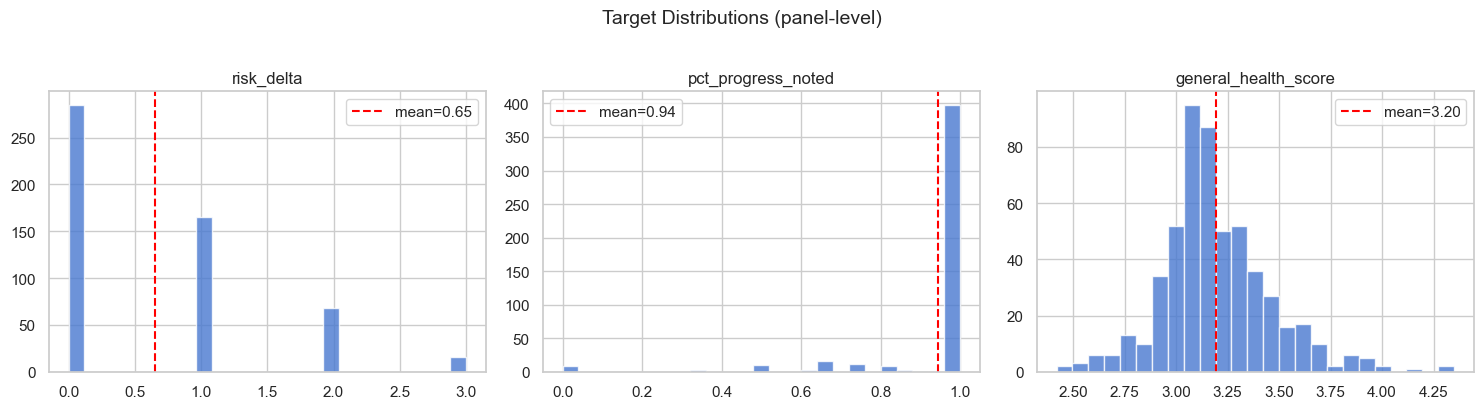

In [3]:
health_feats = ["nutrition_score", "sleep_quality_score", "energy_level_score", "bmi"]
session_feats = ["session_count", "avg_duration_min", "pct_concerns_flagged", "pct_emotional_improvement"]
visit_feats = ["visit_count", "avg_cooperation_score", "pct_safety_concerns", "pct_favorable"]
edu_feats = ["attendance_rate", "progress_percent"]
control_feats = ["initial_risk_numeric", "age_upon_admission_months", "monthly_funding", "case_category_enc"]
target_cols = ["risk_delta", "pct_progress_noted", "general_health_score"]

all_feats = health_feats + session_feats + visit_feats + edu_feats + control_feats
panel_feats = health_feats + session_feats + visit_feats + edu_feats  # no controls for correlation

# Fill visit NaN with 0 (months with no scheduled visit)
for c in visit_feats:
    tl[c] = tl[c].fillna(0)
# Fill session NaN with 0 (months with no sessions)
for c in session_feats:
    tl[c] = tl[c].fillna(0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, target_cols):
    tl[col].dropna().hist(bins=25, ax=ax, edgecolor="white", alpha=0.8)
    ax.set_title(col, fontsize=12)
    ax.axvline(tl[col].mean(), color="red", ls="--", label=f"mean={tl[col].mean():.2f}")
    ax.legend()
plt.suptitle("Target Distributions (panel-level)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

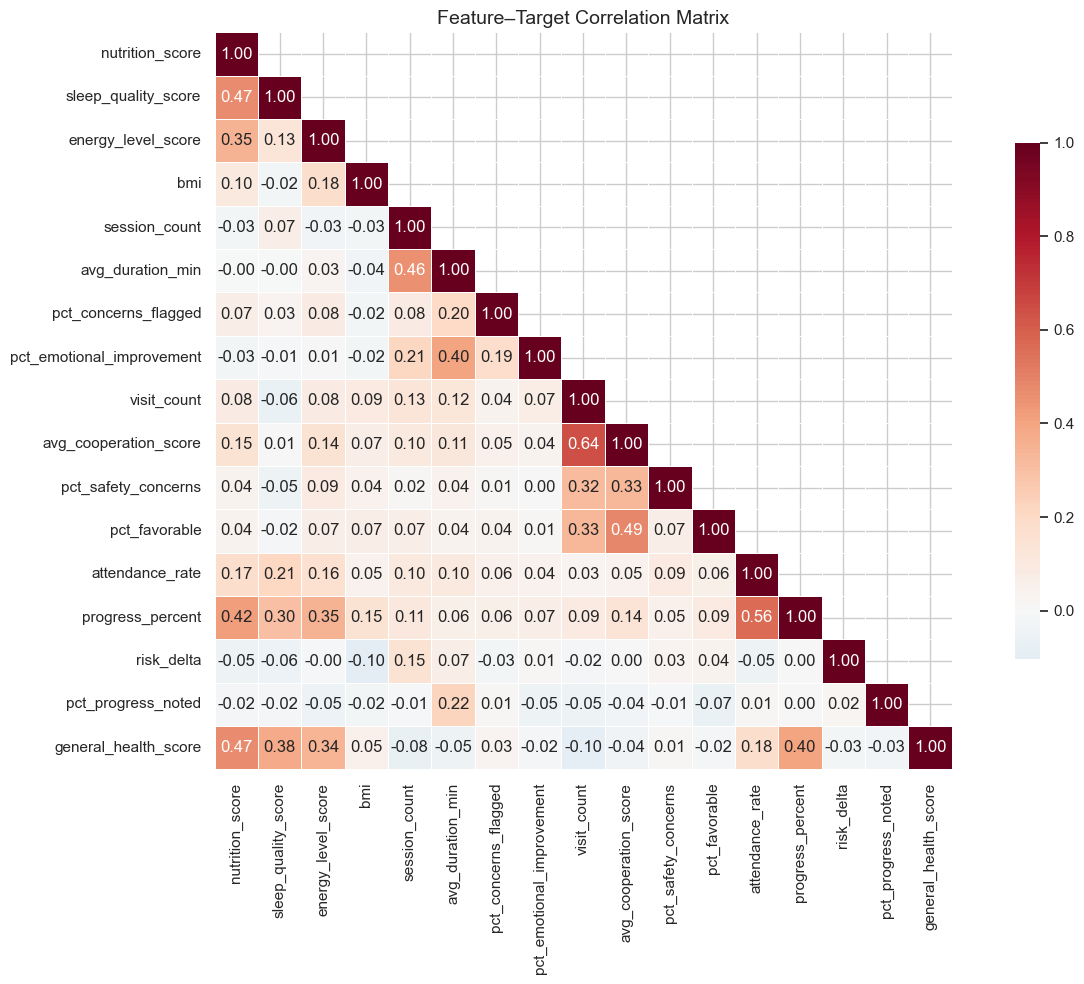


Top absolute correlations with each target:

  risk_delta:
    session_count                   r = +0.151
    bmi                             r = -0.103
    avg_duration_min                r = +0.072
    sleep_quality_score             r = -0.057
    nutrition_score                 r = -0.047

  pct_progress_noted:
    avg_duration_min                r = +0.221
    pct_favorable                   r = -0.065
    energy_level_score              r = -0.054
    visit_count                     r = -0.049
    pct_emotional_improvement       r = -0.045

  general_health_score:
    nutrition_score                 r = +0.471
    progress_percent                r = +0.401
    sleep_quality_score             r = +0.377
    energy_level_score              r = +0.338
    attendance_rate                 r = +0.177


In [4]:
corr_cols = panel_feats + target_cols
corr = tl[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            ax=ax, square=True, linewidths=0.5, cbar_kws={"shrink": 0.7})
ax.set_title("Feature–Target Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

print("\nTop absolute correlations with each target:")
for t in target_cols:
    top = corr[t].drop(target_cols).abs().sort_values(ascending=False).head(5)
    print(f"\n  {t}:")
    for feat, val in top.items():
        print(f"    {feat:30s}  r = {corr[t][feat]:+.3f}")

## 3. Model 1 — Risk Delta (Resident-Level)

**Target:** `risk_delta` = `initial_risk_numeric − current_risk_numeric` (ordinal: 0, 1, 2, 3).

Since each resident has one risk_delta value, we aggregate panel features to resident-level
(mean and OLS slope over the resident's time series), then fit:
- **OLS** for interpretability and coefficient significance
- **Ordinal logistic** (proportional odds) for proper ordinal treatment

In [5]:
def ols_slope(group, y_col):
    g = group.dropna(subset=[y_col])
    if len(g) < 3:
        return np.nan
    x = np.arange(len(g), dtype=float)
    return stats.linregress(x, g[y_col].values.astype(float)).slope

sorted_tl = tl.sort_values(["resident_id", "record_date"])

# Aggregate panel features to resident-level means
agg_mean = sorted_tl.groupby("resident_id")[panel_feats].mean()
agg_mean.columns = [f"{c}_mean" for c in agg_mean.columns]

# Aggregate panel features to resident-level slopes (trend over time)
slope_feats = ["general_health_score", "attendance_rate", "session_count",
               "avg_cooperation_score", "pct_concerns_flagged"]
agg_slope = pd.DataFrame()
for feat in slope_feats:
    slopes = sorted_tl.groupby("resident_id").apply(
        lambda g: ols_slope(g, feat), include_groups=False
    )
    agg_slope[f"{feat}_slope"] = slopes

# Combine into resident-level dataset
res_df = agg_mean.join(agg_slope).reset_index()
res_df = res_df.merge(
    residents[["resident_id", "risk_delta", "initial_risk_numeric",
               "age_upon_admission_months", "length_of_stay_days",
               "case_category"]].drop_duplicates(),
    on="resident_id", how="left"
)
res_df["case_category_enc"] = LabelEncoder().fit_transform(res_df["case_category"].astype(str))
res_df = res_df.dropna(subset=["risk_delta"])

print(f"Resident-level dataset: {res_df.shape}")
print(f"\nrisk_delta distribution:")
print(res_df["risk_delta"].value_counts().sort_index())

Resident-level dataset: (60, 26)

risk_delta distribution:
risk_delta
0    32
1    18
2     8
3     2
Name: count, dtype: int64


### 3a. OLS Regression on Risk Delta

In [6]:
mean_feat_cols = [c for c in res_df.columns if c.endswith("_mean")]
slope_feat_cols = [c for c in res_df.columns if c.endswith("_slope")]
m1_control_cols = ["initial_risk_numeric", "age_upon_admission_months",
                   "length_of_stay_days", "case_category_enc"]
m1_features = mean_feat_cols + slope_feat_cols + m1_control_cols

X_m1 = res_df[m1_features].copy().fillna(0)

# Standardize for comparable coefficients
scaler_m1 = StandardScaler()
X_m1_scaled = pd.DataFrame(scaler_m1.fit_transform(X_m1), columns=X_m1.columns, index=X_m1.index)
X_m1_scaled = sm.add_constant(X_m1_scaled)
y_m1 = res_df["risk_delta"].values

model_m1_ols = sm.OLS(y_m1, X_m1_scaled).fit()
print("=== Model 1a: OLS on risk_delta (resident-level, n={}) ===".format(len(y_m1)))
print(f"R² = {model_m1_ols.rsquared:.3f},  Adj R² = {model_m1_ols.rsquared_adj:.3f}")
print(f"F-stat = {model_m1_ols.fvalue:.2f},  F p-value = {model_m1_ols.f_pvalue:.4f}\n")

coefs_m1 = pd.DataFrame({
    "coef": model_m1_ols.params,
    "std_err": model_m1_ols.bse,
    "t_stat": model_m1_ols.tvalues,
    "p_value": model_m1_ols.pvalues,
    "ci_lower": model_m1_ols.conf_int()[0],
    "ci_upper": model_m1_ols.conf_int()[1],
}).drop("const", errors="ignore")
coefs_m1["sig"] = coefs_m1["p_value"].apply(
    lambda p: "***" if p < 0.01 else ("**" if p < 0.05 else ("*" if p < 0.10 else ""))
)
coefs_m1 = coefs_m1.sort_values("p_value")
print(coefs_m1.round(4).to_string())
print("\nSignificance: *** p<0.01  ** p<0.05  * p<0.10")

=== Model 1a: OLS on risk_delta (resident-level, n=60) ===
R² = 0.624,  Adj R² = 0.384
F-stat = 2.60,  F p-value = 0.0050

                                  coef  std_err  t_stat  p_value  ci_lower  ci_upper  sig
initial_risk_numeric            0.5977   0.1465  4.0800   0.0002    0.3006    0.8948  ***
avg_cooperation_score_slope     0.2346   0.1125  2.0848   0.0442    0.0064    0.4629   **
attendance_rate_mean           -0.2385   0.1696 -1.4062   0.1682   -0.5825    0.1055     
progress_percent_mean           0.2385   0.1765  1.3507   0.1852   -0.1196    0.5965     
length_of_stay_days            -0.1543   0.1206 -1.2792   0.2090   -0.3989    0.0903     
energy_level_score_mean         0.1277   0.1051  1.2159   0.2319   -0.0853    0.3408     
case_category_enc               0.1238   0.1024  1.2092   0.2345   -0.0838    0.3314     
pct_safety_concerns_mean        0.1487   0.1244  1.1950   0.2399   -0.1037    0.4011     
pct_emotional_improvement_mean -0.1146   0.1122 -1.0208   0.3142   

### 3b. Ordinal Logistic Regression on Risk Delta

Proportional-odds model treats risk_delta as properly ordered (0 < 1 < 2 < 3).

In [7]:
# Ordinal logistic — use a reduced feature set to avoid convergence issues with n=60
m1_key_feats = [
    "general_health_score_mean", "attendance_rate_mean",
    "session_count_mean", "avg_cooperation_score_mean",
    "pct_concerns_flagged_mean", "general_health_score_slope",
    "attendance_rate_slope", "initial_risk_numeric",
    "age_upon_admission_months"
]
X_m1_ord = res_df[m1_key_feats].copy().fillna(0)
X_m1_ord_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X_m1_ord), columns=X_m1_ord.columns, index=X_m1_ord.index
)
y_m1_ord = res_df["risk_delta"].astype(int).values

try:
    model_m1_ordinal = OrderedModel(y_m1_ord, X_m1_ord_scaled, distr="logit")
    result_m1_ord = model_m1_ordinal.fit(method="bfgs", disp=False, maxiter=2000)
    print("=== Model 1b: Ordinal Logistic on risk_delta ===")
    print(f"Log-Likelihood: {result_m1_ord.llf:.2f}")
    print(f"AIC: {result_m1_ord.aic:.2f}\n")
    print(result_m1_ord.summary())
except Exception as e:
    print(f"Ordinal logistic did not converge: {e}")
    print("Proceeding with OLS results from Model 1a as primary.")

KeyError: "['general_health_score_mean'] not in index"

## 4. Model 2 — Progress Noted (Panel-Level)

**Target:** `pct_progress_noted` — proportion of sessions in a given month where the social worker
flagged progress (0–1 scale, panel-level n≈534).

Since this is a proportion (bounded 0–1), we use:
- **Fractional logit (GLM Binomial)** — proper treatment of proportional outcomes
- Clustered standard errors by `resident_id` to account for within-resident correlation

Note: pct_progress_noted is right-skewed (mean ≈ 0.94). We binarize as < 1.0 vs = 1.0
for a logistic model of "incomplete progress" months.

In [8]:
m2_feats = (health_feats + ["session_count", "avg_duration_min", "pct_emotional_improvement"]
            + visit_feats + edu_feats
            + ["initial_risk_numeric", "age_upon_admission_months",
               "monthly_funding", "case_category_enc", "incident_count"])

# Drop rows where pct_progress_noted is NaN (months with no sessions)
tl_m2 = tl.dropna(subset=["pct_progress_noted"]).copy()

# Binary outcome: full-progress month (all sessions had progress noted) vs not
tl_m2["full_progress"] = (tl_m2["pct_progress_noted"] >= 1.0).astype(int)
print(f"Model 2 panel: {len(tl_m2)} rows, {tl_m2['resident_id'].nunique()} residents")
print(f"full_progress distribution: {tl_m2['full_progress'].value_counts().to_dict()}")
print(f"  (full=1: {tl_m2['full_progress'].mean():.1%})")

X_m2 = tl_m2[m2_feats].copy().fillna(0)
scaler_m2 = StandardScaler()
X_m2_scaled = pd.DataFrame(scaler_m2.fit_transform(X_m2), columns=X_m2.columns, index=X_m2.index)
X_m2_scaled = sm.add_constant(X_m2_scaled)
y_m2 = tl_m2["full_progress"].values
groups_m2 = tl_m2["resident_id"].values

model_m2 = sm.Logit(y_m2, X_m2_scaled).fit(
    cov_type="cluster", cov_kwds={"groups": groups_m2}, disp=False
)
print(f"\n=== Model 2: Logistic Regression on full_progress (clustered SE) ===")
print(f"Pseudo R² = {model_m2.prsquared:.3f}")
print(f"Log-Likelihood = {model_m2.llf:.2f}")
print(f"AIC = {model_m2.aic:.2f}\n")

coefs_m2 = pd.DataFrame({
    "coef (log-odds)": model_m2.params,
    "odds_ratio": np.exp(model_m2.params),
    "std_err": model_m2.bse,
    "z_stat": model_m2.tvalues,
    "p_value": model_m2.pvalues,
    "ci_lower": np.exp(model_m2.conf_int()[0]),
    "ci_upper": np.exp(model_m2.conf_int()[1]),
}).drop("const", errors="ignore")
coefs_m2["sig"] = coefs_m2["p_value"].apply(
    lambda p: "***" if p < 0.01 else ("**" if p < 0.05 else ("*" if p < 0.10 else ""))
)
coefs_m2 = coefs_m2.sort_values("p_value")
print(coefs_m2.round(4).to_string())
print("\nInterpretation: odds_ratio > 1 means feature increases probability of full progress")
print("Significance: *** p<0.01  ** p<0.05  * p<0.10")

Model 2 panel: 462 rows, 60 residents
full_progress distribution: {1: 398, 0: 64}
  (full=1: 86.1%)

=== Model 2: Logistic Regression on full_progress (clustered SE) ===
Pseudo R² = 0.171
Log-Likelihood = -154.13
AIC = 346.26

                           coef (log-odds)  odds_ratio  std_err  z_stat  p_value  ci_lower  ci_upper  sig
avg_duration_min                    0.9259      2.5240   0.1486  6.2316   0.0000    1.8864    3.3772  ***
session_count                      -0.8576      0.4242   0.1469 -5.8378   0.0000    0.3180    0.5657  ***
visit_count                        -0.2405      0.7862   0.1495 -1.6088   0.1077    0.5866    1.0539     
bmi                                -0.1837      0.8322   0.1269 -1.4473   0.1478    0.6490    1.0672     
case_category_enc                   0.1969      1.2177   0.1419  1.3880   0.1651    0.9221    1.6080     
sleep_quality_score                -0.2108      0.8099   0.1627 -1.2955   0.1951    0.5888    1.1142     
initial_risk_numeric           

## 5. Model 3 — General Health Score (Panel-Level)

**Target:** `general_health_score` — monthly health assessment (continuous, 1–5 scale).

Two estimators:
- **Pooled OLS with clustered SEs** — estimates average effects across all resident-months
- **Fixed-effects (within estimator)** — demeans by resident to control for all
  time-invariant unobserved heterogeneity (e.g., baseline health, genetics, case severity)

In [9]:
# Features: session, visit, education, and control variables
# (exclude other health sub-scores to avoid tautological prediction)
m3_feats = (session_feats + visit_feats + edu_feats
            + ["initial_risk_numeric", "age_upon_admission_months",
               "monthly_funding", "case_category_enc", "incident_count"])

tl_m3 = tl.dropna(subset=["general_health_score"]).copy()
X_m3 = tl_m3[m3_feats].copy().fillna(0)

scaler_m3 = StandardScaler()
X_m3_scaled = pd.DataFrame(scaler_m3.fit_transform(X_m3), columns=X_m3.columns, index=X_m3.index)
X_m3_scaled = sm.add_constant(X_m3_scaled)
y_m3 = tl_m3["general_health_score"].values
groups_m3 = tl_m3["resident_id"].values

# 5a: Pooled OLS with clustered SE
model_m3_pooled = sm.OLS(y_m3, X_m3_scaled).fit(
    cov_type="cluster", cov_kwds={"groups": groups_m3}
)
print("=== Model 3a: Pooled OLS on general_health_score (clustered SE) ===")
print(f"R² = {model_m3_pooled.rsquared:.3f},  Adj R² = {model_m3_pooled.rsquared_adj:.3f}")
print(f"F-stat = {model_m3_pooled.fvalue:.2f},  F p-value = {model_m3_pooled.f_pvalue:.4f}\n")

coefs_m3 = pd.DataFrame({
    "coef": model_m3_pooled.params,
    "std_err": model_m3_pooled.bse,
    "t_stat": model_m3_pooled.tvalues,
    "p_value": model_m3_pooled.pvalues,
    "ci_lower": model_m3_pooled.conf_int()[0],
    "ci_upper": model_m3_pooled.conf_int()[1],
}).drop("const", errors="ignore")
coefs_m3["sig"] = coefs_m3["p_value"].apply(
    lambda p: "***" if p < 0.01 else ("**" if p < 0.05 else ("*" if p < 0.10 else ""))
)
coefs_m3 = coefs_m3.sort_values("p_value")
print(coefs_m3.round(4).to_string())
print("\nSignificance: *** p<0.01  ** p<0.05  * p<0.10")

=== Model 3a: Pooled OLS on general_health_score (clustered SE) ===
R² = 0.237,  Adj R² = 0.215
F-stat = 4.29,  F p-value = 0.0000

                             coef  std_err  t_stat  p_value  ci_lower  ci_upper  sig
progress_percent           0.1254   0.0231  5.4245   0.0000    0.0801    0.1707  ***
monthly_funding            0.0304   0.0119  2.5614   0.0104    0.0071    0.0537   **
visit_count               -0.0284   0.0128 -2.2226   0.0262   -0.0535   -0.0034   **
pct_safety_concerns        0.0166   0.0102  1.6314   0.1028   -0.0033    0.0366     
session_count             -0.0149   0.0095 -1.5651   0.1176   -0.0336    0.0038     
attendance_rate           -0.0209   0.0147 -1.4231   0.1547   -0.0496    0.0079     
age_upon_admission_months -0.0280   0.0210 -1.3347   0.1820   -0.0690    0.0131     
initial_risk_numeric      -0.0338   0.0261 -1.2925   0.1962   -0.0850    0.0174     
incident_count            -0.0097   0.0093 -1.0463   0.2954   -0.0278    0.0085     
avg_cooperation_sc

### 5b. Fixed-Effects Estimator

Demeans each feature and the target by resident-level means, eliminating all
time-invariant confounders (baseline health, demographics, case severity).
Only time-varying features remain — this isolates **within-resident** effects.

In [10]:
# Time-varying features only (controls are time-invariant, dropped by demeaning)
m3_tv_feats = session_feats + visit_feats + edu_feats + ["incident_count", "monthly_funding"]

tl_fe = tl_m3[["resident_id"] + m3_tv_feats + ["general_health_score"]].copy().fillna(0)

# Demean by resident (within transformation)
resident_means = tl_fe.groupby("resident_id")[m3_tv_feats + ["general_health_score"]].transform("mean")
tl_demeaned = tl_fe[m3_tv_feats + ["general_health_score"]] - resident_means
tl_demeaned["resident_id"] = tl_fe["resident_id"].values

X_fe = tl_demeaned[m3_tv_feats].values
y_fe = tl_demeaned["general_health_score"].values
groups_fe = tl_demeaned["resident_id"].values

# No constant (absorbed by demeaning)
model_m3_fe = sm.OLS(y_fe, X_fe).fit(
    cov_type="cluster", cov_kwds={"groups": groups_fe}
)

n_residents = tl_fe["resident_id"].nunique()
n_obs = len(y_fe)
k = len(m3_tv_feats)
dof_fe = n_obs - n_residents - k  # account for absorbed fixed effects
r2_within = 1 - np.sum(model_m3_fe.resid**2) / np.sum((y_fe - y_fe.mean())**2)

print(f"=== Model 3b: Fixed-Effects OLS (within estimator, clustered SE) ===")
print(f"N = {n_obs}, Residents = {n_residents}, DoF = {dof_fe}")
print(f"R² (within) = {r2_within:.3f}\n")

coefs_fe = pd.DataFrame({
    "feature": m3_tv_feats,
    "coef": model_m3_fe.params,
    "std_err": model_m3_fe.bse,
    "t_stat": model_m3_fe.tvalues,
    "p_value": model_m3_fe.pvalues,
})
coefs_fe["sig"] = coefs_fe["p_value"].apply(
    lambda p: "***" if p < 0.01 else ("**" if p < 0.05 else ("*" if p < 0.10 else ""))
)
coefs_fe = coefs_fe.sort_values("p_value")
print(coefs_fe.round(4).to_string(index=False))
print("\nSignificance: *** p<0.01  ** p<0.05  * p<0.10")

=== Model 3b: Fixed-Effects OLS (within estimator, clustered SE) ===
N = 534, Residents = 60, DoF = 462
R² (within) = 0.335

                  feature    coef  std_err  t_stat  p_value sig
         progress_percent  0.0047   0.0006  7.3654   0.0000 ***
pct_emotional_improvement -0.0377   0.0143 -2.6359   0.0084 ***
      pct_safety_concerns  0.0380   0.0178  2.1325   0.0330  **
            pct_favorable  0.0282   0.0192  1.4654   0.1428    
     pct_concerns_flagged  0.0231   0.0159  1.4557   0.1455    
          monthly_funding  0.0000   0.0000  1.2121   0.2255    
              visit_count -0.0041   0.0058 -0.7131   0.4758    
    avg_cooperation_score  0.0034   0.0053  0.6291   0.5293    
          attendance_rate -0.0252   0.0514 -0.4907   0.6236    
           incident_count  0.0089   0.0188  0.4712   0.6375    
            session_count -0.0012   0.0032 -0.3897   0.6968    
         avg_duration_min  0.0000   0.0003  0.1133   0.9098    

Significance: *** p<0.01  ** p<0.05  * p<0

## 6. Cross-Model Comparison of Significant Indicators

Which features are significant across multiple targets?
Features that appear as significant in 2+ models are the strongest causal candidates.

In [11]:
# Collect significant features from each model (p < 0.10)
def extract_sig(coefs_df, model_name, feat_col="index"):
    if feat_col == "index":
        df = coefs_df[coefs_df["p_value"] < 0.10].copy()
        df["feature"] = df.index
    else:
        df = coefs_df[coefs_df["p_value"] < 0.10].copy()
    df["model"] = model_name
    return df[["feature", "model", "p_value"]].reset_index(drop=True)

sig_m1 = extract_sig(coefs_m1, "M1: Risk Delta (OLS)")
sig_m2 = extract_sig(coefs_m2.rename(columns={"coef (log-odds)": "coef"}), "M2: Progress Noted (Logit)")
sig_m3_pooled = extract_sig(coefs_m3, "M3a: Health (Pooled OLS)")
sig_m3_fe = extract_sig(coefs_fe, "M3b: Health (Fixed Effects)", feat_col="feature")

all_sig = pd.concat([sig_m1, sig_m2, sig_m3_pooled, sig_m3_fe], ignore_index=True)

if len(all_sig) > 0:
    # Pivot to see cross-model significance
    pivot = all_sig.pivot_table(
        index="feature", columns="model", values="p_value", aggfunc="first"
    )
    pivot["n_models_sig"] = pivot.notna().sum(axis=1)
    pivot = pivot.sort_values("n_models_sig", ascending=False)

    print("=== Significant Features Across Models (p < 0.10) ===\n")
    display_cols = [c for c in pivot.columns if c != "n_models_sig"]
    formatted = pivot[display_cols].applymap(
        lambda x: f"{x:.4f}" if pd.notna(x) else "—"
    )
    formatted["models_sig"] = pivot["n_models_sig"].astype(int)
    print(formatted.to_string())

    print(f"\n\nFeatures significant in 2+ models:")
    multi = pivot[pivot["n_models_sig"] >= 2].index.tolist()
    if multi:
        for f in multi:
            print(f"  • {f}")
    else:
        print("  (none — features may be target-specific)")
else:
    print("No features reached p < 0.10 in any model.")

=== Significant Features Across Models (p < 0.10) ===

model                       M1: Risk Delta (OLS) M2: Progress Noted (Logit) M3a: Health (Pooled OLS) M3b: Health (Fixed Effects)  models_sig
feature                                                                                                                                     
progress_percent                               —                          —                   0.0000                      0.0000           2
avg_cooperation_score_slope               0.0442                          —                        —                           —           1
avg_duration_min                               —                     0.0000                        —                           —           1
initial_risk_numeric                      0.0002                          —                        —                           —           1
monthly_funding                                —                          —                   0.010

## 7. Diagnostics

### 7a. Multicollinearity (VIF) — Model 3 Pooled OLS features
### 7b. Breusch–Pagan Heteroscedasticity Test — Model 3
### 7c. Residual Normality — Q-Q Plot
### 7d. Residual vs. Fitted Plot

In [ ]:
# 7a. VIF for Model 3 pooled OLS features
X_vif = X_m3_scaled.drop("const", axis=1, errors="ignore")
vif_data = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

print("=== VIF (Model 3: Health Score features) ===")
print("Rule of thumb: VIF > 5 = moderate concern, VIF > 10 = serious\n")
vif_data["flag"] = vif_data["VIF"].apply(
    lambda v: "!!!" if v > 10 else ("!!" if v > 5 else "")
)
print(vif_data.round(2).to_string(index=False))

In [ ]:
# 7b. Breusch-Pagan test for heteroscedasticity (Model 3 pooled)
bp_stat, bp_pval, bp_fstat, bp_fpval = het_breuschpagan(model_m3_pooled.resid, X_m3_scaled)
print("=== Breusch-Pagan Test (Model 3: Health Score) ===")
print(f"LM stat = {bp_stat:.3f},  p-value = {bp_pval:.4f}")
print(f"F stat  = {bp_fstat:.3f},  p-value = {bp_fpval:.4f}")
if bp_pval < 0.05:
    print("→ Evidence of heteroscedasticity (p < 0.05). Clustered SEs are appropriate.")
else:
    print("→ No strong evidence of heteroscedasticity.")

# 7c & 7d. Residual diagnostics
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Q-Q plot for Model 1 (OLS)
sm.qqplot(model_m1_ols.resid, line="45", ax=axes[0], alpha=0.5)
axes[0].set_title("Q-Q: Model 1 (Risk Delta OLS)")

# Q-Q plot for Model 3 (pooled OLS)
sm.qqplot(model_m3_pooled.resid, line="45", ax=axes[1], alpha=0.5)
axes[1].set_title("Q-Q: Model 3 (Health Pooled OLS)")

# Residuals vs. Fitted for Model 3
fitted_m3 = model_m3_pooled.fittedvalues
axes[2].scatter(fitted_m3, model_m3_pooled.resid, alpha=0.3, s=10)
axes[2].axhline(0, color="red", ls="--")
axes[2].set_xlabel("Fitted values")
axes[2].set_ylabel("Residuals")
axes[2].set_title("Residuals vs Fitted: Model 3 (Health)")

plt.tight_layout()
plt.show()

# Normality test
_, p_shapiro_m1 = stats.shapiro(model_m1_ols.resid)
_, p_shapiro_m3 = stats.shapiro(model_m3_pooled.resid)
print(f"\nShapiro-Wilk normality test:")
print(f"  Model 1 residuals: p = {p_shapiro_m1:.4f} {'(normal)' if p_shapiro_m1 > 0.05 else '(non-normal)'}")
print(f"  Model 3 residuals: p = {p_shapiro_m3:.4f} {'(normal)' if p_shapiro_m3 > 0.05 else '(non-normal)'}")

## 8. Summary

**Model 1 (Risk Delta):** Resident-level OLS + ordinal logistic on aggregated means and
slopes of panel features — identifies which long-run trends in health, education,
sessions, and family cooperation predict whether a resident's risk level improved.

**Model 2 (Progress Noted):** Panel logistic with clustered SEs — identifies which
concurrent monthly factors (visit quality, session engagement, education attendance)
predict whether social workers flag full progress in a given month.

**Model 3 (Health Score):** Panel OLS (pooled + fixed-effects) with clustered SEs —
the pooled model captures both between- and within-resident effects; the fixed-effects
model isolates time-varying causal drivers by absorbing all resident-level confounders.

Features appearing as significant across multiple models are the strongest candidates
for causal influence on participant progression and regression risk.